Skipped 0 corrupted images.
Found 460 files belonging to 2 classes.
Using 368 files for training.
Using 92 files for validation.
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 88s 7s/step - acc: 0.7690 - loss: 0.4696 - val_acc: 0.4674 - val_loss: 0.6951
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - acc: 0.8587 - loss: 0.3190 - val_acc: 0.4674 - val_loss: 0.6952
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - acc: 0.8913 - loss: 0.2191 - val_acc: 0.4674 - val_loss: 0.6949
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - acc: 0.9321 - loss: 0.1599 - val_acc: 0.4674 - val_loss: 0.6940
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - acc: 0.9293 - loss: 0.1580 - val_acc: 0.4674 - val_loss: 0.6932
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - acc: 0.9647 - loss: 0.1069 - val_acc: 0.4674 - val_loss: 0.6925
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - acc: 0.9620 - loss: 0.1133 - val_acc: 0.4674 - val_loss: 0.6920
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - acc: 0.

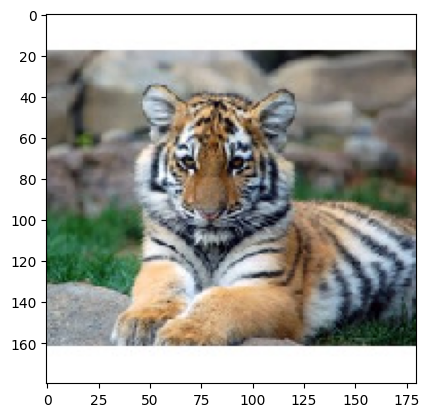

In [24]:
import os
import sys
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

# 1. Point to Kaggle's automatic dataset mount
# Update this path if your dataset is named differently in your Kaggle input folder
dataset_dir = "/kaggle/input/datasets/alekhsub/lion-tiger-dataset/lion_tiger_dataset"

# 2. Filter out corrupted images (Check only, no deleting to avoid read-only errors)
num_skipped = 0
for folder_name in ("Lion", "tiger"):
    folder_path = os.path.join(dataset_dir, folder_name)
    if not os.path.exists(folder_path):
        continue
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        except Exception:
            is_jfif = False
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # os.remove(fpath) # <-- Commented out: Kaggle input is read-only!

print(f"Skipped {num_skipped} corrupted images.")

# 3. Generate a Dataset
image_size = (180, 180)
batch_size = 32  # Lowered from 128 to 32 to prevent underfitting on smaller datasets

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

# 4. Data Augmentation
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Configure the dataset for performance
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

# 5. Build the Model
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])
        previous_block_activation = x

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    units = 1 if num_classes == 2 else num_classes

    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)

model = make_model(input_shape=image_size + (3,), num_classes=2)

# Optional: Disable plot_model if graphviz isn't installed on your Kaggle instance
try:
    keras.utils.plot_model(model, show_shapes=True)
except:
    pass

# 6. Train the model
epochs = 25
callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")],
)
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

# 7. Run inference on new data
# Note: Update this path to an actual image path in your dataset to test it
img_path = os.path.join(dataset_dir, "tiger/tiger_00.jpg") 

img = keras.utils.load_img(img_path, target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = float(keras.ops.sigmoid(predictions[0][0]))

# Lion is class 0, Tiger is class 1
print(f"This image is {100 * score:.2f}% tiger and {100 * (1 - score):.2f}% lion.")

In [ ]:
img_path = os.path.join(dataset_dir, "tiger/tiger_200.jpg") 

img = keras.utils.load_img(img_path, target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = float(keras.ops.sigmoid(predictions[0][0]))

# Lion is class 0, Tiger is class 1
print(f"This image is {100 * score:.2f}% tiger and {100 * (1 - score):.2f}% lion.")